Plotting the traffic matrices for the five workloads
We just want to show the distribution across different pairs of nodes, so the load level should not matter too much?

In [1]:
num_servers = 2988
num_racks = 80
loaddict = {"unv1":1,"prv1":1,"cluster_a":3,"cluster_b":4,"cluster_c":5}
serverfile = "../../../evalserverfiles/dring_2988_80_64.sv"

In [2]:
import numpy as np

serverdict = dict()
with open(serverfile,'r') as f:
    lines = f.readlines()
    for line in lines:
        tokens = line.split(',')
        serverdict[int(tokens[0])] = int(tokens[1])

traffic_matrix_dict = dict()
for cm,load in loaddict.items():
    traffic_matrix = np.zeros((num_racks, num_racks), dtype=int)
    cmfile = f"../eval_main/{cm}/cmfiles/dring_load{load}.cm"
    with open(cmfile,'r') as f:
        lines = f.readlines()
        for line in lines:
            tokens = line.strip().split(',')
            fromserver = int(tokens[0])
            fromrack = serverdict[fromserver]
            toserver = int(tokens[1])
            torack = serverdict[toserver]
            traffic = int(tokens[2])
            traffic_matrix[fromrack,torack] += traffic
    traffic_matrix_dict[cm] = traffic_matrix

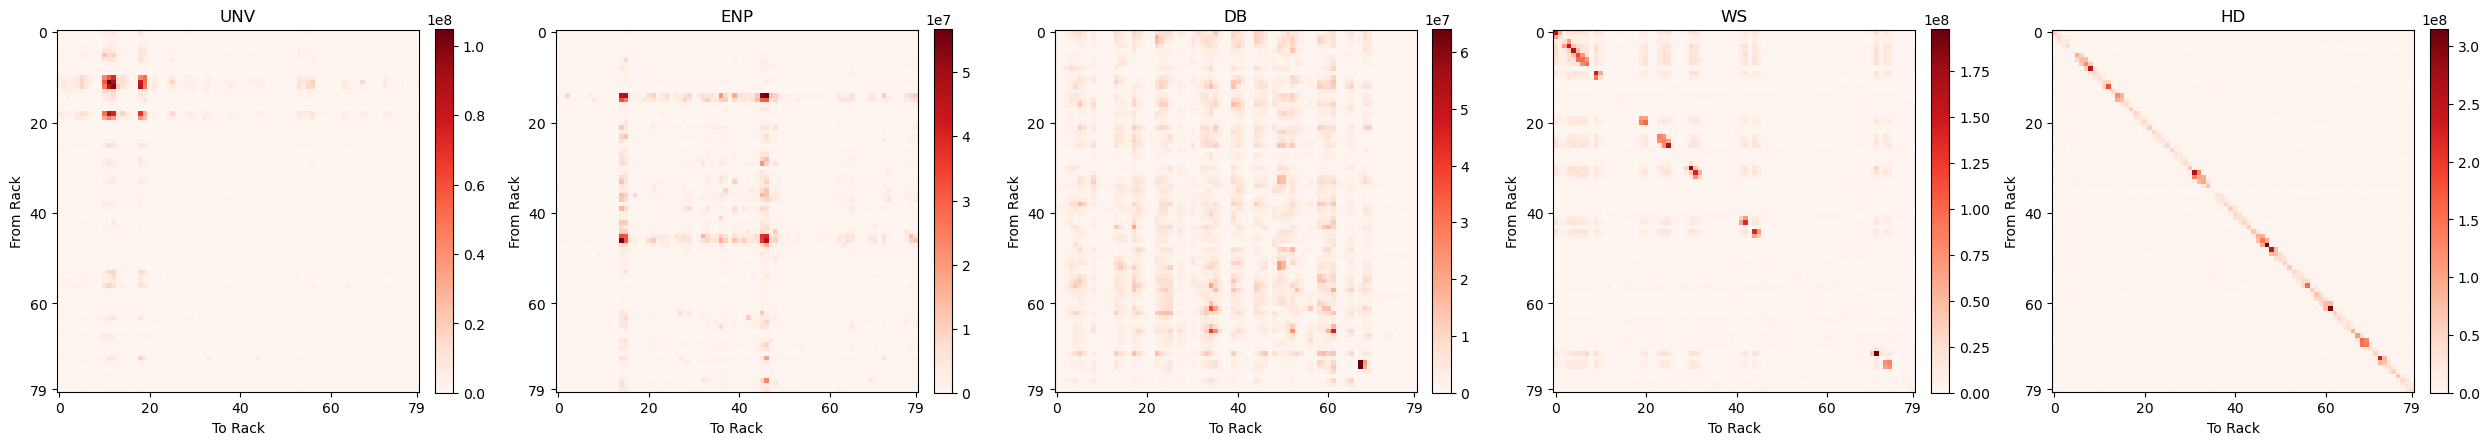

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Assume traffic_matrix_dict is already filled as in your notebook
# Example: traffic_matrix_dict = {'unv1': ..., 'prv1': ..., ...}

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}

workloads = list(traffic_matrix_dict.keys())
num_workloads = len(workloads)

fig, axs = plt.subplots(1, num_workloads, figsize=(num_workloads*5, 5))

if num_workloads == 1:
    axs = [axs]  # Ensure axs is iterable

for idx, cm in enumerate(workloads):
    ax = axs[idx]
    matrix = traffic_matrix_dict[cm]
    im = ax.imshow(matrix, cmap='Reds', interpolation='nearest', vmin=0)
    ax.set_title(plottitledict[cm])
    ax.set_xlabel('To Rack')
    ax.set_ylabel('From Rack')
    ax.set_xticks([0, 20, 40, 60, 79])
    ax.set_yticks([0, 20, 40, 60, 79])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.show()
plt.savefig(f"traffic.pdf", dpi=600, bbox_inches='tight')

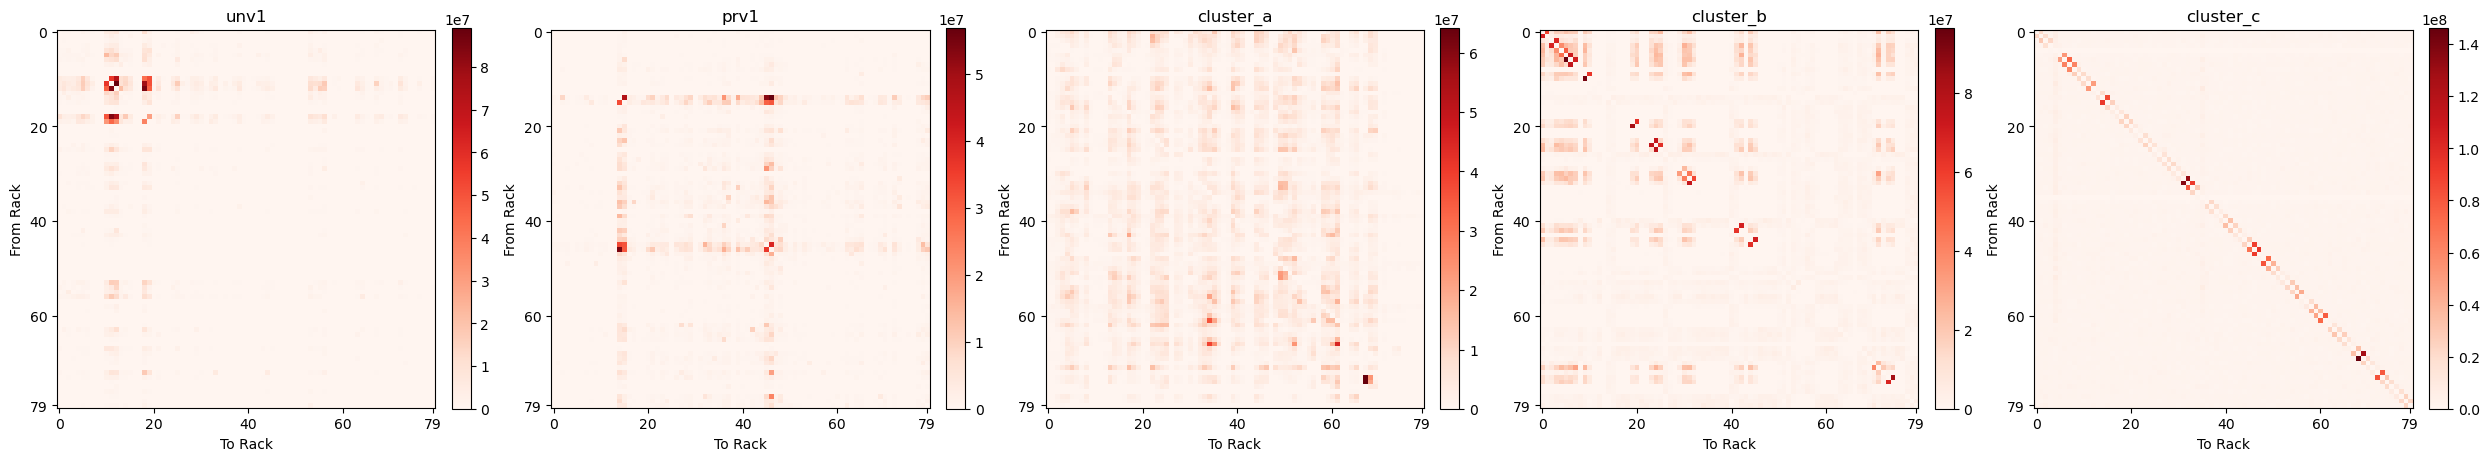

In [17]:
# Plot without intra-rack traffic

import numpy as np

serverdict = dict()
with open(serverfile,'r') as f:
    lines = f.readlines()
    for line in lines:
        tokens = line.split(',')
        serverdict[int(tokens[0])] = int(tokens[1])

traffic_matrix_dict = dict()
for cm,load in loaddict.items():
    traffic_matrix = np.zeros((num_racks, num_racks), dtype=int)
    cmfile = f"../eval_main/{cm}/cmfiles/dring_load{load}.cm"
    with open(cmfile,'r') as f:
        lines = f.readlines()
        for line in lines:
            tokens = line.strip().split(',')
            fromserver = int(tokens[0])
            fromrack = serverdict[fromserver]
            toserver = int(tokens[1])
            torack = serverdict[toserver]
            traffic = int(tokens[2])
            if fromrack != torack:
                traffic_matrix[fromrack,torack] += traffic
    traffic_matrix_dict[cm] = traffic_matrix

import matplotlib.pyplot as plt
import numpy as np

# Assume traffic_matrix_dict is already filled as in your notebook
# Example: traffic_matrix_dict = {'unv1': ..., 'prv1': ..., ...}

workloads = list(traffic_matrix_dict.keys())
num_workloads = len(workloads)

fig, axs = plt.subplots(1, num_workloads, figsize=(num_workloads*5, 5))

if num_workloads == 1:
    axs = [axs]  # Ensure axs is iterable

for idx, cm in enumerate(workloads):
    ax = axs[idx]
    matrix = traffic_matrix_dict[cm]
    im = ax.imshow(matrix, cmap='Reds', interpolation='nearest', vmin=0)
    ax.set_title(cm)
    ax.set_xlabel('To Rack')
    ax.set_ylabel('From Rack')
    ax.set_xticks([0, 20, 40, 60, 79])
    ax.set_yticks([0, 20, 40, 60, 79])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()